# BERT4Rec: Sequential Recommendation with Bidirectional Encoder Representations

## Paper

BERT4Rec: Sequential Recommendation with Bidirectional Encoder
Representations from Transformers

Published in CIKM 2019

Authors:
Fei Sun, Jun Liu, Jian Wu, Changhua Pei, Xiao Lin, Wenwu Ou, Peng Jiang

---

## Objective

Implement BERT4Rec completely from scratch using MovieLens-100K.

BERT4Rec is the **bidirectional** counterpart of SASRec. Instead of
predicting the next item (left-to-right), it masks a subset of items
in the user's history and learns to recover them — exactly like BERT
predicts masked words.

Key ideas:

* Replace next-item prediction with **masked item prediction**.
* Use a **bidirectional** Transformer encoder (no causal mask).
* Apply **dynamic random masking** at training time so the model
  sees fresh masks every epoch.

---

## Pipeline

MovieLens

↓

Sort by Timestamp

↓

User Sequences

↓

Random Masking (15%)

↓

Padding

↓

Item Embedding

+

Position Embedding

↓

Bidirectional Transformer Encoder

↓

Self-Attention (no causal mask)

↓

Hidden States for All Positions

↓

Item Scores (per position)

↓

Masked Item Prediction Loss

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

In [2]:
ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]

)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print("Shape :", ratings.shape)

print()

print(ratings.info())

print()

print("Users :", ratings.user_id.nunique())

print("Movies :", ratings.movie_id.nunique())

Shape : (100000, 4)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Users : 943
Movies : 1682


In [4]:
ratings = ratings.sort_values(

    by=[

        "user_id",

        "timestamp"

    ]

).reset_index(

    drop=True

)

In [5]:
user_mapping = {

    u:i

    for i, u in enumerate(

        ratings.user_id.unique()

    )

}

movie_mapping = {

    m:i+1

    for i, m in enumerate(

        ratings.movie_id.unique()

    )

}

ratings["user_id"] = ratings.user_id.map(

    user_mapping

)

ratings["movie_id"] = ratings.movie_id.map(

    movie_mapping

)

NUM_USERS = ratings.user_id.nunique()

NUM_MOVIES = ratings.movie_id.nunique()

# Special token ids.
#   0              = padding
#   1..NUM_MOVIES  = real movies
#   NUM_MOVIES + 1 = mask token
PAD_TOKEN = 0
MASK_TOKEN = NUM_MOVIES + 1

print(NUM_USERS)
print(NUM_MOVIES)
print("PAD_TOKEN  :", PAD_TOKEN)
print("MASK_TOKEN :", MASK_TOKEN)

943
1682
PAD_TOKEN  : 0
MASK_TOKEN : 1683


In [6]:
user_sequences = (

    ratings

    .groupby(

        "user_id"

    )["movie_id"]

    .apply(list)

)

user_sequences.head()

user_id
0    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
1    [273, 251, 274, 275, 276, 277, 278, 279, 280, ...
2    [309, 307, 317, 318, 126, 319, 280, 320, 321, ...
3    [251, 276, 309, 345, 255, 280, 349, 347, 356, ...
4    [127, 250, 363, 40, 364, 365, 17, 9, 38, 204, ...
Name: movie_id, dtype: object

In [7]:
sequence_lengths = user_sequences.apply(len)

sequence_lengths.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: movie_id, dtype: float64

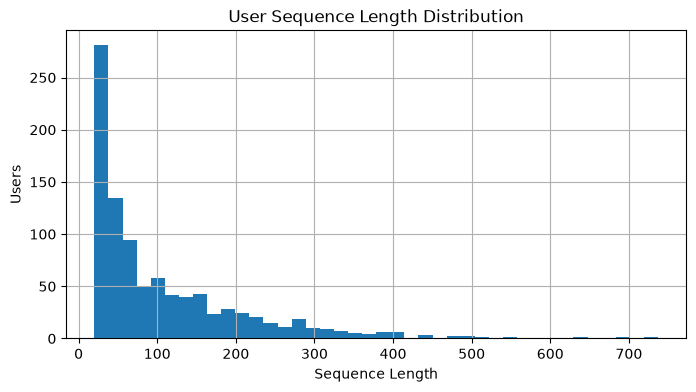

In [8]:
plt.figure(figsize=(8,4))

plt.hist(

    sequence_lengths,

    bins=40

)

plt.xlabel("Sequence Length")

plt.ylabel("Users")

plt.title("User Sequence Length Distribution")

plt.grid(True)

plt.show()

In [9]:
# Keep the full interaction history for every user (one row per user).
# Unlike SASRec we do NOT create sliding-window (history -> next item) pairs.

all_sequences = []

for sequence in user_sequences:

    if len(sequence) < 2:

        continue

    all_sequences.append(sequence)

print("Number of users :", len(all_sequences))
print("First sequence  :", all_sequences[0][:10], "...")


# --- Random masking (15% of items) --------------------------------------
# At every position we flip a coin. If the coin lands within `mask_prob`,
# we replace that item with the MASK_TOKEN and record the original id in
# `labels` so the loss can be computed only on masked positions.

def create_masked_sequence(

    sequence,

    mask_probability=0.15

):

    masked_sequence = sequence.copy()

    labels = [0] * len(sequence)

    for i in range(len(sequence)):

        if np.random.rand() < mask_probability:

            labels[i] = sequence[i]

            masked_sequence[i] = MASK_TOKEN

    return masked_sequence, labels


# Apply the masking once up front. (We will switch to dynamic masking
# inside the Dataset further below so every epoch sees fresh masks.)

masked_sequences = []

labels_list = []

for sequence in all_sequences:

    masked_sequence, label = create_masked_sequence(sequence)

    masked_sequences.append(masked_sequence)

    labels_list.append(label)


# --- Truncate to the last MAX_LEN interactions --------------------------
# Older interactions fall off the left side; the most recent interactions
# remain at the right where they line up with the position embeddings.

MAX_LEN = 50

masked_sequences = [

    seq[-MAX_LEN:]

    for seq in masked_sequences

]

labels_list = [

    lab[-MAX_LEN:]

    for lab in labels_list

]


# --- Pad on the LEFT to MAX_LEN -----------------------------------------
# Padding on the left keeps the most recent interactions at the last
# positions, which line up with the position embeddings.

padded_sequences = []

padded_labels = []

for sequence, label in zip(masked_sequences, labels_list):

    seq_pad = [PAD_TOKEN] * (MAX_LEN - len(sequence))

    lab_pad = [0] * (MAX_LEN - len(label))

    padded_sequences.append(seq_pad + sequence)

    padded_labels.append(lab_pad + label)


padded_sequences = np.array(padded_sequences, dtype=np.int64)
padded_labels = np.array(padded_labels, dtype=np.int64)

print("Sequences :", padded_sequences.shape)
print("Labels    :", padded_labels.shape)

Number of users : 943
First sequence  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] ...
Sequences : (943, 50)
Labels    : (943, 50)


In [10]:
# --- Train / Test Split -------------------------------------------------
# 80% of users go into the training set, 20% into the test set.
# Every user still carries one (masked_sequence, labels) pair.

train_sequences, test_sequences, train_labels, test_labels = train_test_split(

    padded_sequences,

    padded_labels,

    test_size=0.2,

    random_state=42,

    shuffle=True

)

print("Train sequences :", train_sequences.shape)
print("Test sequences  :", test_sequences.shape)
print("Train labels    :", train_labels.shape)
print("Test labels     :", test_labels.shape)

Train sequences : (754, 50)
Test sequences  : (189, 50)
Train labels    : (754, 50)
Test labels     : (189, 50)


In [11]:
# --- BERT4Rec Dataset --------------------------------------------------
# Each item is one user's (masked_sequence, labels) pair. The masking was
# generated once in the cell above, so this is the *static* masking
# variant. To switch to dynamic masking (fresh masks every epoch) see
# the comment at the bottom of this cell.

class BERT4RecDataset(Dataset):

    def __init__(

        self,

        sequences,

        labels

    ):

        self.sequences = sequences

        self.labels = labels

    def __len__(self):

        return len(self.sequences)

    def __getitem__(self, idx):

        return (

            torch.LongTensor(self.sequences[idx]),

            torch.LongTensor(self.labels[idx])

        )


# Dynamic masking (optional upgrade):
#   Re-generate the masked sequence inside __getitem__ so every epoch
#   produces a different mask pattern. To enable it, store the original
#   *un-masked* padded sequences and call create_masked_sequence on
#   them each time. The label is whatever create_masked_sequence returns
#   and any static label entry becomes unused.

In [12]:
# --- DataLoaders --------------------------------------------------------

train_dataset = BERT4RecDataset(

    train_sequences,

    train_labels

)

test_dataset = BERT4RecDataset(

    test_sequences,

    test_labels

)

BATCH_SIZE = 256

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

print("Train batches :", len(train_loader))
print("Test batches  :", len(test_loader))

Train batches : 3
Test batches  : 1


In [13]:
# --- Verify a sample ---------------------------------------------------

batch_sequences, batch_labels = next(iter(train_loader))

print("Batch sequences :", batch_sequences.shape)
print("Batch labels    :", batch_labels.shape)

# Find a sequence that actually contains at least one mask
for i in range(len(train_dataset)):

    seq, lab = train_dataset[i]

    if (seq == MASK_TOKEN).any():

        print("\nExample sample:")
        print("Masked sequence :", seq.tolist())
        print("Labels          :", lab.tolist())
        break

Batch sequences : torch.Size([256, 50])
Batch labels    : torch.Size([256, 50])

Example sample:
Masked sequence : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 309, 215, 146, 99, 250, 90, 620, 473, 568, 1044, 369, 888, 1030, 720, 1683, 1029, 189, 12, 18, 1683, 43, 1683]
Labels          : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 204, 0, 0, 0, 0, 251, 0, 874]


In [14]:
class TransformerBlock(nn.Module):
    """
    A single Transformer encoder block (post-LN variant used by BERT4Rec).

    Unlike SASRec, there is no causal mask — every position may attend to
    every other position, which is what makes the encoder bidirectional.

    Architecture:

        x ──► Multi-Head Self-Attention ──► Dropout ──┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
                              │
                              ▼
        x ──► Feed Forward Network ──► Dropout ──────┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
    """

    def __init__(

        self,

        embedding_dim,

        num_heads,

        dropout,

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads


        # -----------------------------
        # Query
        # -----------------------------

        self.query = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Key
        # -----------------------------

        self.key = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Value
        # -----------------------------

        self.value = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Output Projection
        # -----------------------------

        self.output = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Feed Forward Network
        # -----------------------------

        self.feed_forward = nn.Sequential(

            nn.Linear(

                embedding_dim,

                embedding_dim * 4

            ),

            nn.ReLU(),

            nn.Linear(

                embedding_dim * 4,

                embedding_dim

            )

        )

        # -----------------------------
        # Layer Normalization
        # -----------------------------

        self.layernorm1 = nn.LayerNorm(

            embedding_dim

        )

        self.layernorm2 = nn.LayerNorm(

            embedding_dim

        )

        # -----------------------------
        # Dropout
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

    def forward(

        self,

        x,

        key_mask

    ):

        """
        x:        (batch, seq_len, embedding_dim)
        key_mask: (batch, 1, 1, seq_len) - True for padding key positions
        """

        batch_size, seq_len, _ = x.size()


        # -----------------------------
        # Q, K, V projections
        # -----------------------------

        queries = self.query(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        keys = self.key(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        values = self.value(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )


        # -----------------------------
        # Scaled Dot-Product Attention
        # -----------------------------

        attention_scores = torch.matmul(

            queries,

            keys.transpose(-2, -1)

        )

        attention_scores = attention_scores / math.sqrt(

            self.head_dim

        )

        # -----------------------------
        # Apply padding mask (no causal mask — fully bidirectional)
        # -----------------------------

        attention_scores = attention_scores.masked_fill(

            key_mask,

            float("-inf")

        )

        # -----------------------------
        # Softmax with NaN safety
        # -----------------------------
        # With LEFT padding, position 0 may be padding. After masking the
        # padding key, position 0's row becomes entirely masked ->
        # softmax(-inf) -> NaN. Replace NaN with 0 so the attention
        # output stays finite (padding queries contribute 0).

        attention_weights = F.softmax(

            attention_scores,

            dim=-1

        )

        attention_weights = torch.nan_to_num(

            attention_weights,

            nan=0.0

        )

        attention_weights = self.dropout(

            attention_weights

        )


        attention_output = torch.matmul(

            attention_weights,

            values

        )

        attention_output = attention_output.transpose(

            1,

            2

        ).contiguous().view(

            batch_size,

            seq_len,

            self.embedding_dim

        )


        # -----------------------------
        # Output projection + dropout
        # -----------------------------

        attention_output = self.dropout(

            self.output(

                attention_output

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm1(

            x + attention_output

        )


        # -----------------------------
        # Feed Forward + dropout
        # -----------------------------

        ffn_output = self.dropout(

            self.feed_forward(

                x

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm2(

            x + ffn_output

        )


        return x


class BERT4Rec(nn.Module):
    """
    BERT4Rec: Sequential Recommendation with Bidirectional Encoder
    Representations from Transformers.

    Paper: Sun et al., "BERT4Rec: Sequential Recommendation with
           Bidirectional Encoder Representations from Transformers",
           CIKM 2019.

    Key differences from SASRec:
      1. No causal mask — every position attends to every other
         position (bidirectional context).
      2. The embedding table has `num_items + 2` rows to also
         accommodate the [MASK] token.
      3. `forward` returns the hidden states for *all* positions
         `(batch, seq_len, embedding_dim)`, not just the last one,
         because we predict the original item at every masked
         position (like BERT predicts every masked word).
    """

    def __init__(

        self,

        num_items,

        max_len,

        embedding_dim=64,

        num_heads=4,

        num_blocks=2,

        dropout=0.2

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.max_len = max_len

        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads

        self.num_blocks = num_blocks


        # -----------------------------
        # Item Embedding
        # -----------------------------
        # +2 because of PAD_TOKEN (0) and MASK_TOKEN (num_items + 1).

        self.item_embedding = nn.Embedding(

            num_items + 2,

            embedding_dim,

            padding_idx=PAD_TOKEN

        )


        # -----------------------------
        # Position Embedding
        # -----------------------------

        self.position_embedding = nn.Embedding(

            max_len,

            embedding_dim

        )

        # -----------------------------
        # Stacked Transformer Blocks
        # -----------------------------

        self.blocks = nn.ModuleList(

            [

                TransformerBlock(

                    embedding_dim,

                    num_heads,

                    dropout

                )

                for _ in range(num_blocks)

            ]

        )

        # -----------------------------
        # Dropout (applied to input embeddings)
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

        self._init_weights()


    def _init_weights(self):
        """
        Initialize weights following standard Transformer / BERT4Rec
        conventions.

        - Linear layers: Xavier-uniform on weights, zeros on biases.
        - Embeddings:    Normal(0, 0.02), with padding_idx row zeroed.
        """

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(

                    module.weight

                )

                if module.bias is not None:

                    nn.init.zeros_(

                        module.bias

                    )

            elif isinstance(module, nn.Embedding):

                nn.init.normal_(

                    module.weight,

                    mean=0.0,

                    std=0.02

                )

                if module.padding_idx is not None:

                    with torch.no_grad():

                        module.weight[

                            module.padding_idx

                        ].zero_()


    def forward(

        self,

        sequences

    ):

        """
        sequences: (batch, seq_len) - LongTensor of item ids.
        Returns:   (batch, seq_len, embedding_dim) - hidden state for
                   every position. The caller is responsible for pooling
                   (BERT4Rec keeps the full sequence).
        """

        batch_size, seq_len = sequences.size()


        # -----------------------------
        # Item + Position embeddings
        # -----------------------------

        item_embeddings = self.item_embedding(

            sequences

        )

        position_ids = torch.arange(

            seq_len,

            device=sequences.device

        ).unsqueeze(0).expand(

            batch_size,

            seq_len

        )

        position_embeddings = self.position_embedding(

            position_ids

        )

        x = self.dropout(

            item_embeddings + position_embeddings

        )


        # -----------------------------
        # Build padding mask
        # -----------------------------
        # Padding mask: True for non-padding positions, shape
        # (batch, seq_len).

        padding_mask = sequences != PAD_TOKEN


        # Key mask: True for padding positions (to mask as keys).
        # Shape (batch, 1, 1, seq_len) for broadcasting over heads and
        # queries.

        key_mask = (~padding_mask).unsqueeze(1).unsqueeze(1)


        # -----------------------------
        # Pass through stacked transformer blocks
        # (no causal mask — fully bidirectional)
        # -----------------------------

        for block in self.blocks:

            x = block(

                x,

                key_mask

            )


        # -----------------------------
        # Return hidden states for ALL positions
        # -----------------------------
        # Unlike SASRec, we do not pick the last position. Every
        # position carries its own prediction head output for the
        # masked-item loss.

        return x

## What Changed vs. SASRec

The model is refactored into two classes:

- **`TransformerBlock`** — a reusable block that owns its own Q/K/V/Output/FFN/LayerNorm/Dropout. **No causal mask** — attention is fully bidirectional.
- **`BERT4Rec`** — composes item + position embeddings with `nn.ModuleList([... num_blocks ...])`. Returns `(batch, seq_len, embedding_dim)` so every position can predict a movie.

### Component-by-component changes

| Component | Change |
|---|---|
| **Causal mask** | Removed. Every position attends to every position. |
| **Item embedding** | `num_items + 2` (added a row for the `[MASK]` token). |
| **Return shape** | `(batch, seq_len, embedding_dim)` instead of `(batch, embedding_dim)` — we keep all hidden states. |
| **Padding mask** | Kept. `key_mask` (shape `(batch, 1, 1, seq_len)`) is applied to attention scores. |
| **Dropout** | After Output Projection and after FFN. |
| **Transformer stack** | `num_blocks` is a constructor argument (default `2`). |
| **Initialization** | Linear → Xavier-uniform; Embedding → `Normal(0, 0.02)` with `padding_idx` row zeroed. |

### Where the prediction head lives

`BERT4Rec.forward` returns `(batch, seq_len, embedding_dim)` — one hidden state per position. The score against every item is computed *outside* the model, exactly like SASRec and LightGCN:

```python
scores = torch.matmul(hidden, model.item_embedding.weight.T)  # (batch, seq_len, num_items+2)
```

### Subtlety: NaN from fully-masked rows

With **left-padding**, position 0 can be padding. The padding key mask then fully masks position 0's row → `softmax(-inf)` → `NaN` → the whole LayerNorm output goes `NaN`.

The fix is one line:

```python
attention_weights = torch.nan_to_num(attention_weights, nan=0.0)
```

In [15]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model = BERT4Rec(

    num_items=NUM_MOVIES,

    max_len=MAX_LEN,

    embedding_dim=64,

    num_heads=4,

    num_blocks=2,

    dropout=0.2

).to(device)

model

BERT4Rec(
  (item_embedding): Embedding(1684, 64, padding_idx=0)
  (position_embedding): Embedding(50, 64)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (query): Linear(in_features=64, out_features=64, bias=True)
      (key): Linear(in_features=64, out_features=64, bias=True)
      (value): Linear(in_features=64, out_features=64, bias=True)
      (output): Linear(in_features=64, out_features=64, bias=True)
      (feed_forward): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
)

In [16]:
# Sanity check: instantiate the model and run one forward pass.

batch_sequences, batch_labels = next(

    iter(train_loader)

)

hidden = model(

    batch_sequences.to(device)

)

print("Input shape       :", batch_sequences.shape)
print("Hidden shape      :", hidden.shape)
print("Number of blocks  :", model.num_blocks)
print("Has NaN           :", torch.isnan(hidden).any().item())
print("Number of params  :", sum(p.numel() for p in model.parameters()))

Input shape       : torch.Size([256, 50])
Hidden shape      : torch.Size([256, 50, 64])
Number of blocks  : 2
Has NaN           : False
Number of params  : 210944


In [17]:
scores = torch.matmul(

    hidden,

    model.item_embedding.weight.T

)

print("Scores shape :", scores.shape)
# (batch, seq_len, num_items + 2) — every position scores every item.

Scores shape : torch.Size([256, 50, 1684])


In [18]:
# Mask out the PAD_TOKEN column so it is never predicted.
scores[:, :, PAD_TOKEN] = -1e9

print("Scores shape :", scores.shape)

Scores shape : torch.Size([256, 50, 1684])


In [19]:
# CrossEntropy with ignore_index=0 so we only compute loss on masked
# positions. label == 0 means "this position was not masked" and is
# silently skipped by PyTorch.
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [20]:
# Flatten to (batch * seq_len, num_items + 2) and (batch * seq_len,)
# so CrossEntropy can compare them element-wise.
scores_flat = scores.view(-1, NUM_MOVIES + 2)
labels_flat = batch_labels.to(device).view(-1)

loss = criterion(scores_flat, labels_flat)
print("Loss :", loss.item())

Loss : 7.445181369781494


In [21]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-5

)

In [22]:
NUM_EPOCHS = 20

train_losses = []

train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for sequences, labels in train_loader:

        sequences = sequences.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        # 1. Forward: hidden states for every position
        hidden = model(sequences)

        # 2. Scores: (batch, seq_len, num_items + 2)
        scores = torch.matmul(

            hidden,

            model.item_embedding.weight.T

        )

        # 3. Never predict the PAD column
        scores[:, :, PAD_TOKEN] = -1e9

        # 4. Flatten for CrossEntropy
        scores_flat = scores.view(-1, NUM_MOVIES + 2)

        labels_flat = labels.view(-1)

        # 5. Masked-item prediction loss (ignore_index=0)
        loss = criterion(scores_flat, labels_flat)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        # 6. Accuracy only on masked positions
        predictions = scores_flat.argmax(dim=1)

        valid = labels_flat != 0

        correct += (

            predictions[valid] == labels_flat[valid]

        ).sum().item()

        total += valid.sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = correct / max(total, 1)

    train_losses.append(epoch_loss)

    train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"| Loss: {epoch_loss:.4f} "
        f"| Masked Accuracy: {epoch_accuracy:.4f}"
    )

Epoch [1/20] | Loss: 7.4195 | Masked Accuracy: 0.0004
Epoch [2/20] | Loss: 7.3038 | Masked Accuracy: 0.0021
Epoch [3/20] | Loss: 7.1848 | Masked Accuracy: 0.0042
Epoch [4/20] | Loss: 7.0751 | Masked Accuracy: 0.0050
Epoch [5/20] | Loss: 6.9747 | Masked Accuracy: 0.0048
Epoch [6/20] | Loss: 6.8883 | Masked Accuracy: 0.0046
Epoch [7/20] | Loss: 6.8144 | Masked Accuracy: 0.0050
Epoch [8/20] | Loss: 6.7531 | Masked Accuracy: 0.0054
Epoch [9/20] | Loss: 6.7034 | Masked Accuracy: 0.0069
Epoch [10/20] | Loss: 6.6595 | Masked Accuracy: 0.0052
Epoch [11/20] | Loss: 6.6226 | Masked Accuracy: 0.0064
Epoch [12/20] | Loss: 6.5866 | Masked Accuracy: 0.0073
Epoch [13/20] | Loss: 6.5584 | Masked Accuracy: 0.0081
Epoch [14/20] | Loss: 6.5269 | Masked Accuracy: 0.0066
Epoch [15/20] | Loss: 6.4965 | Masked Accuracy: 0.0089
Epoch [16/20] | Loss: 6.4612 | Masked Accuracy: 0.0077
Epoch [17/20] | Loss: 6.4325 | Masked Accuracy: 0.0098
Epoch [18/20] | Loss: 6.3976 | Masked Accuracy: 0.0114
Epoch [19/20] | Los

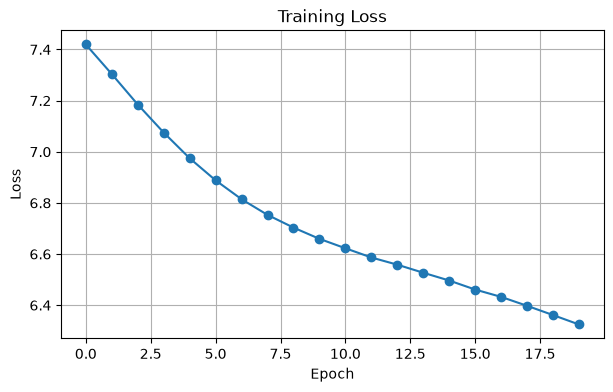

In [23]:
plt.figure(figsize=(7,4))

plt.plot(

    train_losses,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

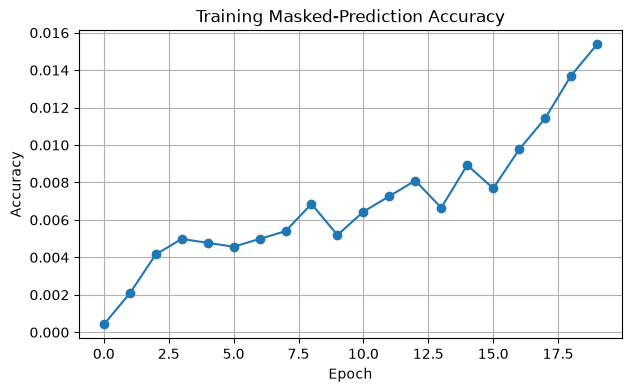

In [24]:
plt.figure(figsize=(7,4))

plt.plot(

    train_accuracies,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Masked-Prediction Accuracy")

plt.grid(True)

plt.show()

In [25]:
model.eval()

test_correct = 0

test_total = 0

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)

        labels = labels.to(device)

        hidden = model(sequences)

        scores = torch.matmul(

            hidden,

            model.item_embedding.weight.T

        )

        scores[:, :, PAD_TOKEN] = -1e9

        scores_flat = scores.view(-1, NUM_MOVIES + 2)

        labels_flat = labels.view(-1)

        predictions = scores_flat.argmax(dim=1)

        valid = labels_flat != 0

        test_correct += (

            predictions[valid] == labels_flat[valid]

        ).sum().item()

        test_total += valid.sum().item()

test_accuracy = test_correct / max(test_total, 1)

print(f"Test Masked Accuracy : {test_accuracy:.4f}")

Test Masked Accuracy : 0.0042


In [26]:
K = 10

hits = []

model.eval()

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)

        labels = labels.to(device)

        hidden = model(sequences)

        scores = torch.matmul(

            hidden,

            model.item_embedding.weight.T

        )

        scores[:, :, PAD_TOKEN] = -1e9

        # top-K item indices per position
        topk = torch.topk(scores, K, dim=-1).indices

        # Iterate over batch and positions; skip non-masked positions
        for b in range(labels.size(0)):

            for t in range(labels.size(1)):

                target = labels[b, t].item()

                if target == 0:

                    continue

                if target in topk[b, t].tolist():

                    hits.append(1)

                else:

                    hits.append(0)

hitrate = float(np.mean(hits)) if hits else 0.0

print(f"HitRate@{K} : {hitrate:.4f}")

HitRate@10 : 0.0722


In [27]:
K = 10

ndcg_scores = []

model.eval()

with torch.no_grad():

    for sequences, labels in test_loader:

        sequences = sequences.to(device)

        labels = labels.to(device)

        hidden = model(sequences)

        scores = torch.matmul(

            hidden,

            model.item_embedding.weight.T

        )

        scores[:, :, PAD_TOKEN] = -1e9

        topk = torch.topk(scores, K, dim=-1).indices

        for b in range(labels.size(0)):

            for t in range(labels.size(1)):

                target = labels[b, t].item()

                if target == 0:

                    continue

                ranking = topk[b, t].tolist()

                if target in ranking:

                    rank = ranking.index(target)

                    ndcg_scores.append(1 / np.log2(rank + 2))

                else:

                    ndcg_scores.append(0)

ndcg = float(np.mean(ndcg_scores)) if ndcg_scores else 0.0

print(f"NDCG@{K} : {ndcg:.4f}")

NDCG@10 : 0.0326


In [28]:
print("="*40)
print(f"Test Masked Accuracy : {test_accuracy:.4f}")
print(f"HitRate@10           : {hitrate:.4f}")
print(f"NDCG@10              : {ndcg:.4f}")
print("="*40)

Test Masked Accuracy : 0.0042
HitRate@10           : 0.0722
NDCG@10              : 0.0326
